In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
sns.set_theme(style="whitegrid")

In [4]:
def sanity_checks(df: pd.DataFrame):
  """Prints basic dataset metadata, shape, missing values, and descriptive statistics."""
  print("=" * 60)
  print("MULTI-TICKER DATASET SANITY CHECKS")
  print("=" * 60)
  print(f"Master Dataset Shape: {df.shape}")
  print(f"Tickers Included: {df['ticker'].unique().tolist()}")
  print(f"Date Range: {df.index.min()} -> {df.index.max()}")
  print(f"\nMissing Values:\n{df.isna().sum()}")
  print(
      "\nFeature Statistics Across All Tickers:\n"
      f"{df[['log_return', 'rolling_vol', 'volume_zscore', 'target_future_vol']].describe()}"
  )

In [5]:
def price_and_volatility(df: pd.DataFrame, ticker: str = "AAPL"):
  """Plots Close Price and Rolling Realized Volatility stacked vertically for a specific ticker."""
  sub_df = df[df["ticker"] == ticker]
  if sub_df.empty:
    print(f"Warning: Ticker {ticker} not found in dataset for plotting.")
    return

  fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
  axes[0].plot(sub_df.index, sub_df["Close"], color="steelblue")
  axes[0].set_title(f"{ticker} — Close Price (200-Day Window)")
  axes[0].set_ylabel("Price")

  axes[1].plot(sub_df.index, sub_df["rolling_vol"], color="firebrick")
  axes[1].set_title(
      f"{ticker} — Rolling Realized Volatility (Trailing 10-Day Std of Log"
      " Returns)"
  )
  axes[1].set_ylabel("Volatility")

  plt.tight_layout()
  plt.savefig(f"{ticker.lower()}_price_and_volatility.png", dpi=120)
  plt.show()

In [6]:
def log_return_distribution(df: pd.DataFrame):
  """Plots the distribution and KDE curve of log returns across the master dataset."""
  plt.figure(figsize=(8, 5))
  sns.histplot(df["log_return"], bins=80, kde=True, color="steelblue")
  plt.title("Distribution of Log Returns (All Tickers)")
  plt.xlabel("Log Return")
  plt.ylabel("Frequency")
  plt.tight_layout()
  plt.savefig("master_log_return_distribution.png", dpi=120)
  plt.show()

In [7]:
def target_distribution(df: pd.DataFrame):
  """Plots the distribution of the target variable to inspect right-skewness."""
  plt.figure(figsize=(8, 5))
  sns.histplot(df["target_future_vol"], bins=80, kde=True, color="firebrick")
  plt.title("Distribution of Target Future Volatility (Checking Right-Skew)")
  plt.xlabel("Future Realized Volatility")
  plt.ylabel("Frequency")
  plt.tight_layout()
  plt.savefig("master_target_distribution.png", dpi=120)
  plt.show()

In [8]:
def acf_pacf(df: pd.DataFrame, ticker: str = "AAPL"):
  """Generates ACF and PACF plots for a specific ticker's rolling volatility."""
  sub_df = df[df["ticker"] == ticker]
  fig, axes = plt.subplots(1, 2, figsize=(14, 4))
  plot_acf(sub_df["rolling_vol"].dropna(), lags=30, ax=axes[0])
  axes[0].set_title(f"Autocorrelation (ACF) of Rolling Volatility ({ticker})")

  plot_pacf(sub_df["rolling_vol"].dropna(), lags=30, ax=axes[1])
  axes[1].set_title(
      f"Partial Autocorrelation (PACF) of Rolling Volatility ({ticker})"
  )

  plt.tight_layout()
  plt.savefig(f"{ticker.lower()}_acf_pacf_volatility.png", dpi=120)
  plt.show()

In [9]:
def feature_vs_target_scatter(df: pd.DataFrame):
  """Generates a scatter plot of past vs. future volatility as a sanity check against data leakage."""
  plt.figure(figsize=(6, 6))
  plt.scatter(
      df["rolling_vol"],
      df["target_future_vol"],
      alpha=0.2,
      s=8,
      color="darkorange",
  )
  plt.xlabel("rolling_vol (Past)")
  plt.ylabel("target_future_vol (Future)")
  plt.title("Past Vol vs Future Vol (Master Dataset)")
  plt.tight_layout()
  plt.savefig("master_feature_vs_target_scatter.png", dpi=120)
  plt.show()

In [10]:
def volume_zscore_distribution(df: pd.DataFrame):
  """Plots the distribution of volume Z-scores to examine outlier metrics."""
  plt.figure(figsize=(8, 5))
  sns.histplot(df["volume_zscore"], bins=80, kde=True, color="seagreen")
  plt.title("Distribution of Volume Z-Scores (Master Dataset)")
  plt.xlabel("Volume Z-Score")
  plt.ylabel("Frequency")
  plt.tight_layout()
  plt.savefig("master_volume_zscore_distribution.png", dpi=120)
  plt.show()

In [11]:
def correlation_heatmap(df: pd.DataFrame):
  """Generates a correlation heatmap for all engineered features and targets."""
  plt.figure(figsize=(6, 5))
  corr = df[[
      "log_return",
      "rolling_vol",
      "volume_zscore",
      "target_future_vol",
  ]].corr()
  sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
  plt.title("Feature Correlation Heatmap (Master Dataset)")
  plt.tight_layout()
  plt.savefig("master_correlation_heatmap.png", dpi=120)
  plt.close()

In [14]:
def full_eda(df: pd.DataFrame, primary_ticker):
  """Orchestrator function that executes all EDA components sequentially."""
  sanity_checks(df)
  price_and_volatility(df, ticker=primary_ticker)
  log_return_distribution(df)
  target_distribution(df)
  acf_pacf(df)
  feature_vs_target_scatter(df)
  volume_zscore_distribution(df)
  correlation_heatmap(df)

Fetching historical daily bars for AAPL over a 200d window...
Fetching historical daily bars for MSFT over a 200d window...
Fetching historical daily bars for GOOGL over a 200d window...
Fetching historical daily bars for NVDA over a 200d window...

200-Day Multi-Ticker Pipeline Complete! Master dataset shape: (720, 10)
MULTI-TICKER DATASET SANITY CHECKS
Master Dataset Shape: (720, 10)
Tickers Included: ['AAPL', 'MSFT', 'GOOGL', 'NVDA']
Date Range: 2025-12-12 00:00:00 -> 2026-09-01 00:00:00

Missing Values:
Price
Close                0
High                 0
Low                  0
Open                 0
Volume               0
log_return           0
rolling_vol          0
volume_zscore        0
target_future_vol    0
ticker               0
dtype: int64

Feature Statistics Across All Tickers:
Price  log_return  rolling_vol  volume_zscore  target_future_vol
count  720.000000   720.000000     720.000000         720.000000
mean     0.000635     0.019331      -0.023590           0.019357
std

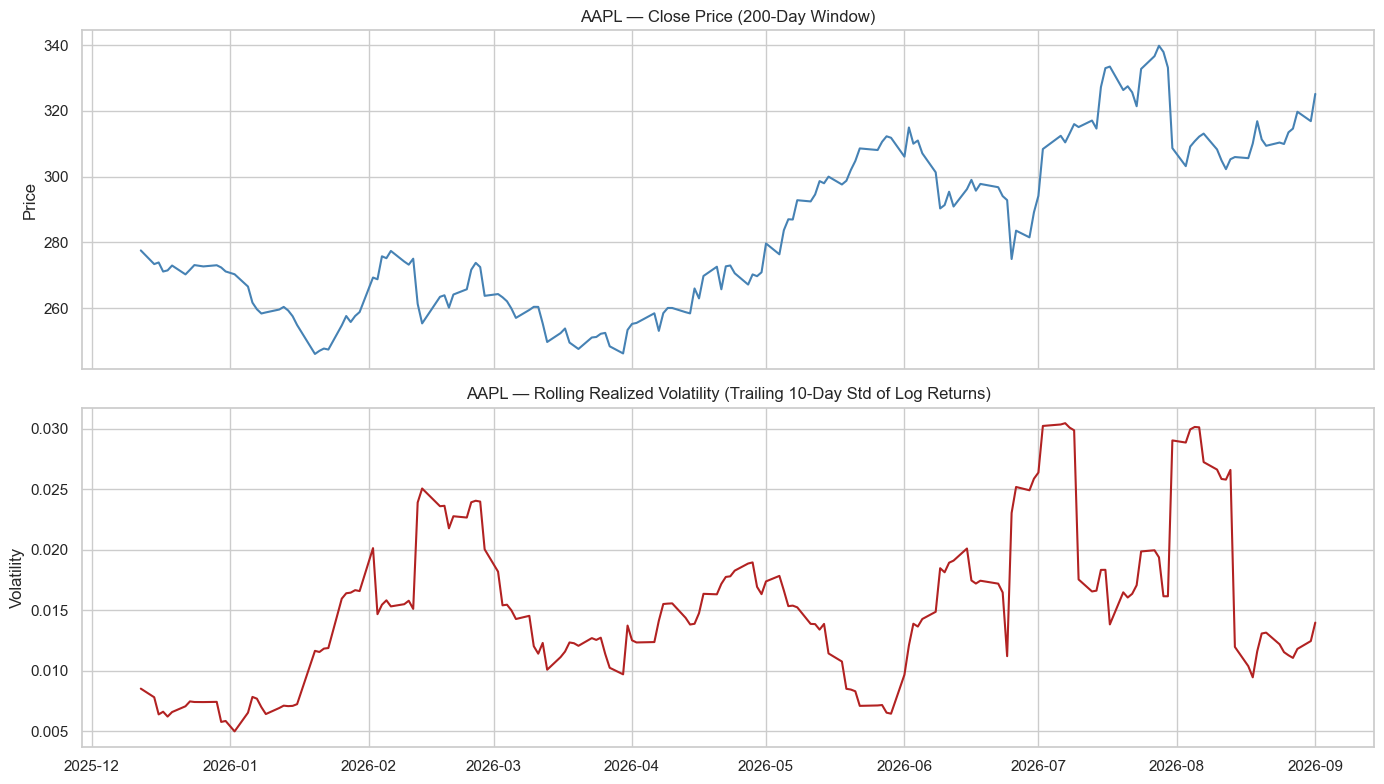

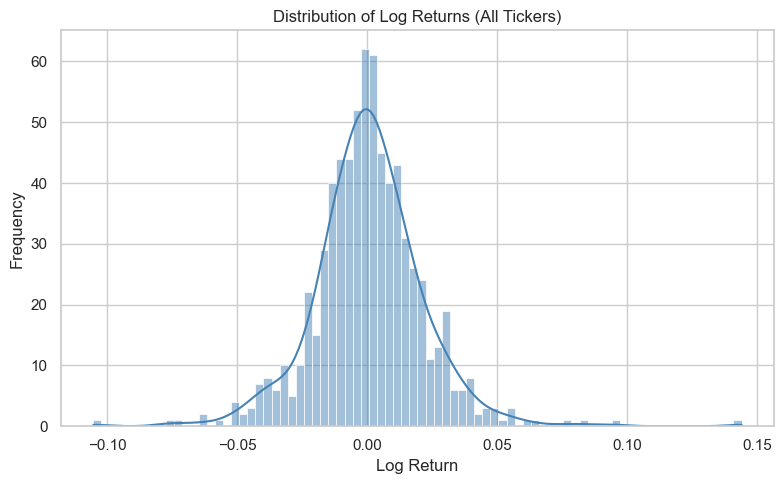

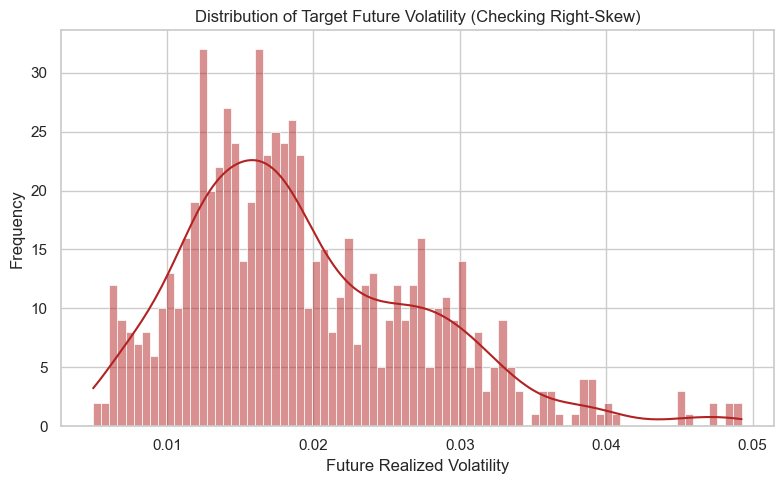

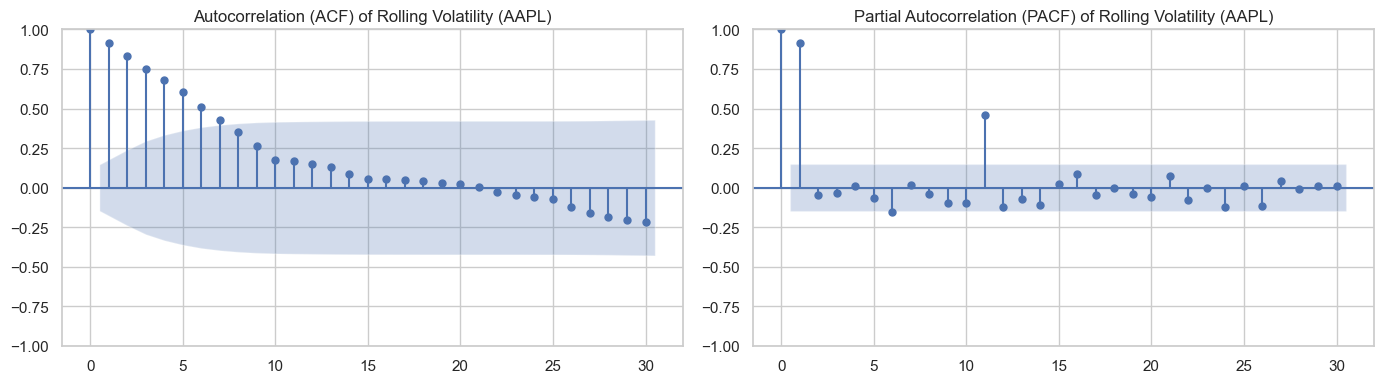

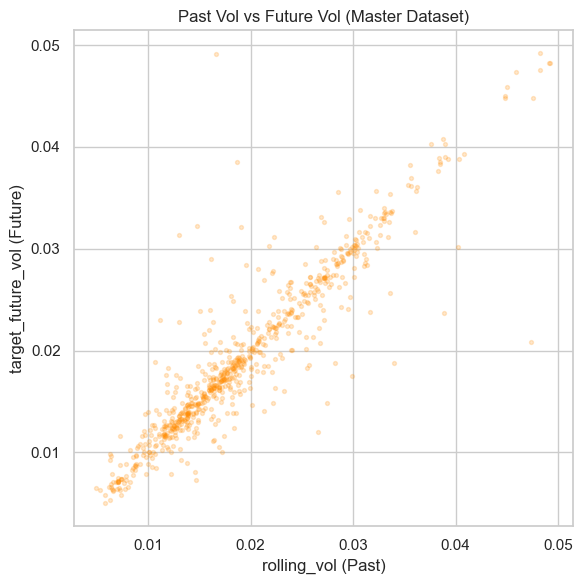

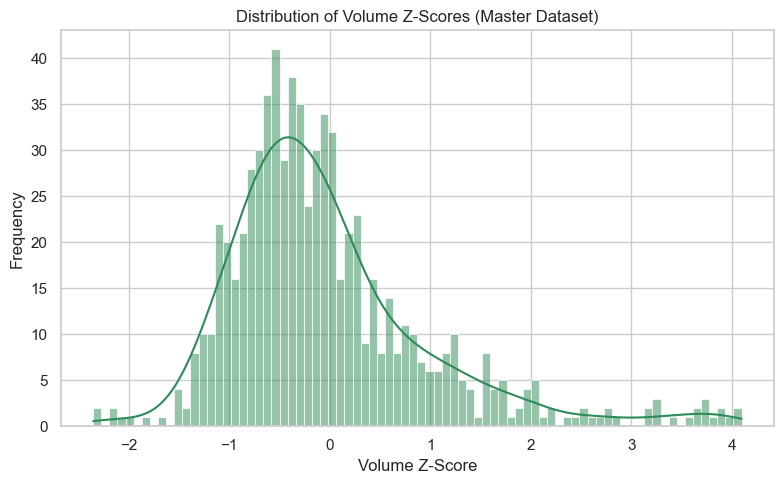

In [15]:
if __name__ == "__main__":
  # Import your updated multi-ticker daily pipeline function
  from train_pipeline import generate_multi_ticker_daily_pipeline

  master_dataset = generate_multi_ticker_daily_pipeline(
      ["AAPL", "MSFT", "GOOGL", "NVDA"], period="200d"
  )
  full_eda(master_dataset, primary_ticker="AAPL")

## Observation:

- The overall trajectory has shifted upwards 
- The leverage effect is clear as the prices fall the volatility shoots up

- Log return appears Leptokurtic i.e. the ordinary days are far calmer and more clustered around zero than a normal distribution would expect 
- Short fat tails at either ends suggests there are outliers 

## Future relaized volatility:

- Volatility is mathematically bounded at zero—it can never be negative. This creates a natural barrier on the left side where values bunch up tightly in calm market regimes (concentrated around $0.010$ to $0.018$).
- The Long Right Tail: Notice how the tail stretches out significantly toward $0.050$. These represent high-stress market shock periods where volatility explodes upward.



## Quantile LSTM Volatility Forecasting

### Feature Engineering:
- Log Returns (log_return): Ensures price stationarity across time
- Rolling Realized Volatility (rolling_vol): Measures trailing standard deviation to capture clustering regimes.
- Volume Z-Score (volume_zscore): Acts as an automated outlier detector for sudden liquidity spikes or market stress.
- Target Variable (target_future_vol): The future rolling volatility window the model is tasked with predicting.

### Key EDA insights 
- The Leverage Effect: Volatility doesn't stay flat; it shoots up violently when the market falls (asymmetric risk).
- Leptokurtic & Fat-Tailed Returns: Log returns are not normally distributed. Normal days are hyper-calm, but extreme multi-sigma crashes happen way more often than a bell curve predicts.
- Right-Skewed Target Volatility: Future volatility is bounded at zero on the low end and stretches out into long, chaotic right tails during market panics.

### How the Standard LSTM fails

Standard LSTMs are trained using Mean Squared Error (MSE), meaning they try to predict the mathematical average, here is the Blind Spot, since markets are calm 90% of the time, a standard LSTM learns to always guess a safe, low average volatility. When a sudden crash happens, it gets completely blindsided because it completely ignores the dangerous edges (tail risks)

An MSE loss function squares every error. If the model wants to get the best overall score with the least amount of effort, it realizes a brilliant shortcut: always guess the low, boring average.

By always guessing the calm average, the model is technically "correct" most of the time because most days are calm. It never has to learn why markets crash or how to spot a panic, because the penalty for missing a rare crash gets drowned out by all the easy points it racks up on calm days. It takes the lazy way out.



## Quantile LSTM:

Instead of predicting a single average number, a Quantile LSTM outputs multiple probabilistic risk boundaries (e.g., the 10th percentile for calm markets, the 90th percentile for crisis ceilings).

The Secret Sauce (Pinball Loss):

- Unlike MSE, Pinball Loss allows asymmetric penalization.
- When training for high stress (τ=0.90), the model is heavily penalized if it under-forecasts a volatility spike.

- The model might "cry wolf" or slightly over-predict during calm days, but it will never miss a crash.
- It trades perfection in quiet times for absolute safety and early warning capability during market panics.


## Pinball Loss:

Pinball Loss is a loss function that penalizes underprediction and overprediction differently, depending on the quantile you care about.

Asymmetric (Pinball Loss): Asymmetric means the penalty depends entirely on which direction you are wrong, and by how much.
